<h1 style="text-align: center; color: purple;">End-to-End Credit Risk MLOps System</h1>

<h2 style="text-align: center; color: green;">Data Drift Detection using PSI & CSI (Model Monitoring)</h2>

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### PSI (Population Stabilty Index)

**Purpose:** Measures the change in the distribution of model prediction probabilities between two different periods.

**Focus:** Primarily on the model's prediction probabilities (scores).

**Usage:**

**Model Monitoring:** Compare reference prediction probabilities with prediction probabilities from new incoming data.

**Model Testing/Validation:** Compare prediction probabilities from the reference period with those from test or validation data.

**Key Point:** PSI helps monitor whether the distribution of model predictions remains stable over time. A significant shift may indicate data drift or potential model degradation.

In [67]:
df_reference_probabilities = pd.read_csv("data/train_probabilities.csv")
df_test_probabilities = pd.read_csv("data/test_probabilities.csv")

In [68]:
df_reference_probabilities.columns = ['probability']
df_test_probabilities.columns = ['probability']

In [69]:
df_reference_probabilities.head(5)

,probability
0,0.000170
1,0.000005
2,0.001406
3,0.226943
4,0.000273


In [70]:
df_test_probabilities.head(5)

,probability
0,0.530388
1,0.000011
2,0.005516
3,0.006468
4,0.921477


In [71]:
df_reference_probabilities.shape

(68390, 1)

In [72]:
df_test_probabilities.shape

(12497, 1)

In [73]:
reference_probabilities = df_reference_probabilities['probability'].to_numpy()
reference_probabilities

array([1.70220986e-04, 5.49840800e-06, 1.40608029e-03, ...,
       5.79523819e-01, 9.85969381e-01, 5.45847082e-01], shape=(68390,))

In [74]:
test_probabilities = df_test_probabilities['probability'].to_numpy()
test_probabilities

array([5.30387738e-01, 1.13741471e-05, 5.51618053e-03, ...,
       2.30195207e-03, 8.36266471e-01, 5.87664994e-01], shape=(12497,))

In [75]:
# Create 10 bins using the reference probabilities

reference_bins = np.percentile(reference_probabilities, np.arange(0, 101, 10))
reference_bins

array([8.46086278e-10, 4.02381494e-06, 8.74129940e-05, 1.82997462e-03,
       5.32545916e-02, 6.03632299e-01, 8.92262699e-01, 9.67170529e-01,
       9.90929450e-01, 9.98718522e-01, 9.99999998e-01])

In [76]:
# Assign reference probabilities to bins

reference_bins_labels = range(1, 11)

reference_binned = pd.cut(reference_probabilities,bins=reference_bins,labels=reference_bins_labels,include_lowest=True)
reference_binned

[3, 2, 3, 5, 3, ..., 9, 7, 5, 8, 5]
Length: 68390
Categories (10, int64): [1 < 2 < 3 < 4 ... 7 < 8 < 9 < 10]

In [77]:
# Calculate the reference percentage for each bin

reference_bin_percentages = (pd.Series(reference_binned).value_counts(normalize=True).sort_index())
reference_bin_percentages

1     0.1
2     0.1
3     0.1
4     0.1
5     0.1
6     0.1
7     0.1
8     0.1
9     0.1
10    0.1
Name: proportion, dtype: float64

In [78]:
# Apply the same bin cutoffs to the test probabilities

test_binned = pd.cut(test_probabilities,bins=reference_bins,labels=reference_bins_labels,include_lowest=True)
test_binned

[5, 2, 4, 4, 7, ..., 3, 2, 4, 6, 5]
Length: 12497
Categories (10, int64): [1 < 2 < 3 < 4 ... 7 < 8 < 9 < 10]

In [79]:
# calculate the test percentage for each bin

test_bin_percentages = (pd.Series(test_binned).value_counts(normalize=True).sort_index())
test_bin_percentages

1     0.177897
2     0.187020
3     0.186140
4     0.179497
5     0.139165
6     0.045935
7     0.027849
8     0.019766
9     0.017446
10    0.019286
Name: proportion, dtype: float64

In [80]:
# Calculate PSI contribution for each bin

psi_by_bin = ((reference_bin_percentages - test_bin_percentages)* np.log(reference_bin_percentages / test_bin_percentages))
psi_by_bin

1     0.044871
2     0.054478
3     0.053521
4     0.046505
5     0.012943
6     0.042060
7     0.092236
8     0.130074
9     0.144147
10    0.132837
Name: proportion, dtype: float64

In [81]:
# Calculate total PSI

psi = psi_by_bin.sum()
print(f"PSI: {psi:.4f}")

PSI: 0.7537


**PSI Interpretation Summary:**

The calculated PSI value is **0.7537**, indicating a significant shift in the distribution of model prediction probabilities between the reference and test populations. This suggests the presence of substantial data drift and the need for further investigation to identify the underlying factors contributing to the observed shift and to assess its potential impact on model performance.

### CSI (Characteristic Stability Index)

CSI follows a process similar to PSI. The key difference is that CSI is calculated separately for each independent feature used by the final model. Each feature is analyzed individually by comparing its distribution between the reference and test periods. The CSI value is then calculated for each feature to identify any significant shifts in its distribution.

In [82]:
# Load reference and test feature data

df_reference_features = pd.read_csv("../dataset/train_data.csv")
df_test_features = pd.read_csv("../dataset/test_data.csv")

In [83]:
df_reference_features.head(5)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_type,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
0,0.788462,M,Married,Self-Employed,0.6,Owned,0.966667,Hyderabad,Telangana,0.661017,...,Secured,0.415094,0.613386,1.000000,1.0,0.375,0.363636,0.414520,0.132,0.59
1,0.500000,F,Single,Salaried,0.0,Owned,0.866667,Mumbai,Maharashtra,0.491525,...,Secured,0.830189,0.025205,0.666667,0.5,0.500,0.050505,0.306792,0.062,0.62
2,0.384615,M,Single,Salaried,0.0,Mortgage,0.833333,Chennai,Tamil Nadu,0.830508,...,Secured,0.490566,0.174318,0.000000,0.5,0.375,0.000000,0.758782,0.222,0.56
3,0.461538,M,Married,Salaried,0.4,Mortgage,0.966667,Bangalore,Karnataka,0.762712,...,Secured,0.641509,0.077523,0.666667,0.0,0.875,0.878788,0.194379,0.000,0.00
4,0.769231,M,Married,Self-Employed,0.8,Owned,0.933333,Pune,Maharashtra,0.510169,...,Unsecured,0.169811,0.072271,0.000000,1.0,0.000,0.717172,0.046838,0.000,0.00


In [84]:
df_test_features.head(5)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_type,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
0,0.346154,M,Married,Self-Employed,0.6,Owned,0.766667,Jaipur,Rajasthan,0.325424,...,Secured,0.754717,0.100520,0.333333,0.5,0.500,0.989899,0.550351,0.000,0.00
1,0.480769,F,Single,Self-Employed,0.0,Owned,0.733333,Delhi,Delhi,0.000000,...,Secured,0.226415,0.127789,1.000000,0.0,0.500,0.323232,0.220141,0.000,0.00
2,0.230769,M,Married,Self-Employed,0.8,Owned,0.866667,Delhi,Delhi,0.000000,...,Secured,0.547170,0.125398,0.666667,0.0,0.625,0.828283,0.180328,0.000,0.00
3,0.365385,F,Single,Salaried,0.4,Owned,0.133333,Pune,Maharashtra,0.510169,...,Secured,0.754717,0.018942,1.000000,1.0,0.750,0.484848,0.571429,0.024,0.70
4,0.576923,F,Single,Salaried,0.0,Mortgage,0.733333,Chennai,Tamil Nadu,0.830508,...,Secured,0.716981,0.031015,0.666667,0.5,0.875,0.979798,0.407494,0.107,0.64


In [85]:
df_reference_features.shape

(37488, 21)

In [86]:
df_test_features.shape

(12497, 21)

In [87]:
df_reference_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37488 entries, 0 to 37487
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  float64
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  float64
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  float64
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  float64
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  loan_tenure_months           37488 non-null  float64
 13  bank_balance_at_

In [88]:
df_test_features.info

<bound method DataFrame.info of             age gender marital_status employment_status  number_of_dependants  \
0      0.346154      M        Married     Self-Employed                   0.6   
1      0.480769      F         Single     Self-Employed                   0.0   
2      0.230769      M        Married     Self-Employed                   0.8   
3      0.365385      F         Single          Salaried                   0.4   
4      0.576923      F         Single          Salaried                   0.0   
...         ...    ...            ...               ...                   ...   
12492  0.173077      M         Single     Self-Employed                   0.0   
12493  0.423077      M         Single     Self-Employed                   0.0   
12494  0.192308      M        Married     Self-Employed                   1.0   
12495  0.250000      M         Single          Salaried                   0.2   
12496  0.384615      M        Married          Salaried                   0.6

In [89]:
selected_features = ["age","residence_type","loan_purpose","loan_type","loan_tenure_months","number_of_open_accounts","credit_utilization_ratio","loan_to_income","delinquency_ratio","avg_dpd_per_delinquency"]

In [90]:
numerical_features = df_reference_features[selected_features].select_dtypes(
    include=["number"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['age', 'loan_tenure_months', 'number_of_open_accounts', 'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency']


In [91]:
categorical_features = df_reference_features[selected_features].select_dtypes(
    include=["object"]
).columns.tolist()

print("\nCategorical features:")
print(categorical_features)


Categorical features:
['residence_type', 'loan_purpose', 'loan_type']


#### Numerical Features

In [92]:
for feature in numerical_features:
    print(feature, ":", df_reference_features[feature].nunique())

age : 53
loan_tenure_months : 54
number_of_open_accounts : 4
credit_utilization_ratio : 100
loan_to_income : 419
delinquency_ratio : 611
avg_dpd_per_delinquency : 84


In [93]:
feature = "number_of_open_accounts"

reference_distribution = (df_reference_features[feature].value_counts(normalize=True).sort_index())

test_distribution = (df_test_features[feature].value_counts(normalize=True).sort_index())

reference_distribution

number_of_open_accounts
0.000000    0.250107
0.333333    0.248106
0.666667    0.250694
1.000000    0.251094
Name: proportion, dtype: float64

In [94]:
test_distribution = (df_test_features["number_of_open_accounts"].value_counts(normalize=True).sort_index())

test_distribution

number_of_open_accounts
0.000000    0.251980
0.333333    0.251820
0.666667    0.248540
1.000000    0.247659
Name: proportion, dtype: float64

In [95]:
csi_values = (
    (reference_distribution - test_distribution)
    * np.log(reference_distribution / test_distribution))

csi_values

number_of_open_accounts
0.000000    0.000014
0.333333    0.000055
0.666667    0.000019
1.000000    0.000047
Name: proportion, dtype: float64

In [96]:
total_open_accounts_csi = csi_values.sum()

print(f"CSI: {total_open_accounts_csi:.4f}")

CSI: 0.0001


In [97]:
for feature in numerical_features:
    if feature != "number_of_open_accounts":
        print(feature)

age
loan_tenure_months
credit_utilization_ratio
loan_to_income
delinquency_ratio
avg_dpd_per_delinquency


In [98]:
# Automated CSI Calculation for Numerical Features

def calculate_numeric_csi(reference, test, bins=10):
    unique_values = reference.nunique()

    if unique_values < bins:
        reference_distribution = (reference.value_counts(normalize=True).sort_index())
        test_distribution = (test.value_counts(normalize=True).sort_index())

        reference_distribution, test_distribution = (reference_distribution.align(test_distribution,fill_value=0))

    else:
        reference_bins = pd.qcut(reference,q=bins,duplicates="drop")
        reference_distribution = (reference_bins.value_counts(normalize=True,sort=False))
        bin_edges = reference_bins.cat.categories
        test_bins = pd.cut(test,bins=bin_edges)
        test_distribution = (test_bins.value_counts(normalize=True,sort=False))

    reference_distribution = reference_distribution.replace(0, 1e-10)
    test_distribution = test_distribution.replace(0, 1e-10)

    csi = ((reference_distribution - test_distribution)* np.log(reference_distribution / test_distribution))

    return csi.sum()

In [99]:
numeric_csi = {}

for feature in numerical_features:
    numeric_csi[feature] = calculate_numeric_csi(df_reference_features[feature],df_test_features[feature])

for feature, csi in numeric_csi.items():
    print(f"{feature:<30} {csi:.4f}")

age                            0.0671
loan_tenure_months             0.0421
number_of_open_accounts        0.0001
credit_utilization_ratio       0.0076
loan_to_income                 0.0015
delinquency_ratio              0.0010
avg_dpd_per_delinquency        0.0249


#### Categorical Features

In [100]:
feature = "residence_type"
reference_distribution = (df_reference_features[feature].value_counts(normalize=True))

print("Reference distribution:")
print(reference_distribution)

Reference distribution:
residence_type
Owned       0.564847
Mortgage    0.236262
Rented      0.198890
Name: proportion, dtype: float64


In [101]:
test_distribution = (df_test_features[feature].value_counts(normalize=True).reindex(reference_distribution.index, fill_value=0))

print("Test distribution:")
print(test_distribution)

Test distribution:
residence_type
Owned       0.569737
Mortgage    0.236777
Rented      0.193486
Name: proportion, dtype: float64


In [102]:
residence_type_csi = ((reference_distribution - test_distribution)* np.log(reference_distribution / test_distribution))
residence_type_csi

residence_type
Owned       0.000042
Mortgage    0.000001
Rented      0.000149
Name: proportion, dtype: float64

In [103]:
total_residence_type_csi = residence_type_csi.sum()

print(f"Total CSI for residence_type: {total_residence_type_csi:.4f}")

Total CSI for residence_type: 0.0002


In [104]:
# Automate the same calculation for all 3 categorical features

categorical_csi_details = {}
categorical_csi_totals = {}

for feature in categorical_features:

    # Reference distribution
    reference_distribution = (
        df_reference_features[feature]
        .value_counts(normalize=True)
    )

    # Test distribution using the same categories
    test_distribution = (
        df_test_features[feature]
        .value_counts(normalize=True)
        .reindex(reference_distribution.index, fill_value=0)
    )

    # CSI contribution for each category
    csi_contribution = (
        (reference_distribution - test_distribution)
        * np.log(reference_distribution / test_distribution)
    )

    # Store category-level CSI
    categorical_csi_details[feature] = csi_contribution

    # Store total CSI for the feature
    categorical_csi_totals[feature] = csi_contribution.sum()

In [105]:
for feature, csi_values in categorical_csi_details.items():

    print(feature)
    print("-" * len(feature))

    for category, csi in csi_values.items():
        print(f"{category:<12} {csi:.6f}")

    print()

residence_type
--------------
Owned        0.000042
Mortgage     0.000001
Rented       0.000149

loan_purpose
------------
Personal     0.000005
Home         0.000048
Auto         0.000000
Education    0.000154

loan_type
---------
Secured      0.000003
Unsecured    0.000005



In [106]:
categorical_csi_df = pd.DataFrame(list(categorical_csi_totals.items()),columns=["Categorical Feature", "CSI"])
categorical_csi_df["CSI"] = categorical_csi_df["CSI"].round(4)

categorical_csi_df

,Categorical Feature,CSI
0,residence_type,0.0002
1,loan_purpose,0.0002
2,loan_type,0.0000


In [107]:
# CSI Summary

# Create numerical CSI DataFrame
numeric_csi_df = pd.DataFrame(list(numeric_csi.items()),columns=["Feature", "CSI"])

# Create categorical CSI DataFrame
categorical_csi_df = pd.DataFrame(list(categorical_csi_totals.items()),columns=["Feature", "CSI"])

# Combine both
csi_summary = pd.concat([numeric_csi_df, categorical_csi_df],ignore_index=True)

# Round CSI values
csi_summary["CSI"] = csi_summary["CSI"].round(4)

# Display final CSI Summary
csi_summary

,Feature,CSI
0,age,0.0671
1,loan_tenure_months,0.0421
2,number_of_open_accounts,0.0001
3,credit_utilization_ratio,0.0076
4,loan_to_income,0.0015
5,delinquency_ratio,0.0010
6,avg_dpd_per_delinquency,0.0249
7,residence_type,0.0002
8,loan_purpose,0.0002
9,loan_type,0.0000


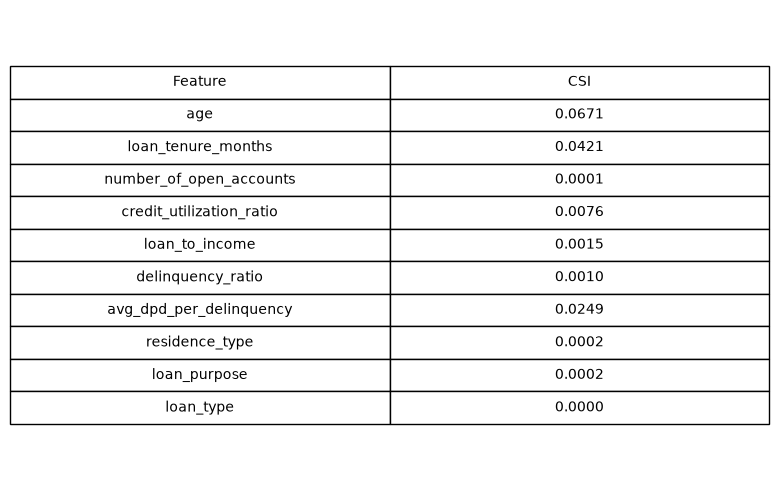

In [108]:
# Create numerical CSI DataFrame
numeric_csi_df = pd.DataFrame(list(numeric_csi.items()),columns=["Feature", "CSI"])

# Create categorical CSI DataFrame
categorical_csi_df = pd.DataFrame(list(categorical_csi_totals.items()),columns=["Feature", "CSI"])

# Combine both
csi_summary = pd.concat([numeric_csi_df, categorical_csi_df],ignore_index=True)

# Format CSI values to exactly 4 decimal places
csi_display = csi_summary.copy()
csi_display["CSI"] = csi_display["CSI"].map(lambda x: f"{x:.4f}")

# Create table
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis("off")

table = ax.table(cellText=csi_display.values,colLabels=csi_display.columns,cellLoc="center",loc="center")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.6)

plt.tight_layout()

# Save image
plt.savefig("../images/characteristic_stability_index_csi_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [109]:
# Sort CSI Summary from highest to lowest

csi_summary = csi_summary.sort_values(by="CSI",ascending=False).reset_index(drop=True)
csi_summary

,Feature,CSI
0,age,0.067058
1,loan_tenure_months,0.042140
2,avg_dpd_per_delinquency,0.024869
3,credit_utilization_ratio,0.007626
4,loan_to_income,0.001520
5,delinquency_ratio,0.001031
6,loan_purpose,0.000207
7,residence_type,0.000192
8,number_of_open_accounts,0.000135
9,loan_type,0.000008


**CSI Interpretation Summary:**

The following guidelines can be used to determine the extent of distributional shift in a variable based on its CSI value.

**CSI < 0.1:** Very slight or no change in the variable's distribution. No immediate action is required.

**CSI between 0.1 and 0.2:** Indicates a slight distributional change. Frequent monitoring is recommended.

**CSI > 0.2:** Indicates a significant distributional change. In the case of CSI, this may indicate a need to investigate the variable further and consider model redevelopment or removal of the variable, depending on the impact on model performance.

**Note:** Ideal rules do not always work in real-life scenarios. While it is good practice to follow the above ranges, the appropriate thresholds depend on factors such as the Line of Business (LOB) for which the model was developed, the quality and quantity of the data, and the model's performance acceptance criteria. All these factors should be considered when determining the appropriate thresholds. It is generally advisable to have an internal discussion to establish and agree upon the threshold rules, as applying standard threshold guidelines may not always be practical in real-world scenarios.

The CSI analysis shows that all 10 features have CSI values below 0.1, indicating that their distributions remained relatively stable between the reference and test populations, with very little or no significant distributional change. The highest CSI was observed for `age` at 0.0671, followed by `loan_tenure_months` at 0.0421 and `avg_dpd_per_delinquency` at 0.0249. However, all three values remain below the 0.1 threshold and therefore do not indicate a significant distributional shift.

## PSI Analysis – Further Investigation

#### Bin-level PSI Analysis

In [110]:
# Reference prediction probability distribution

reference_probability_distribution = (
    df_reference_probabilities.iloc[:, 0].value_counts(normalize=True).sort_index())

reference_probability_distribution

probability
8.460863e-10    0.000015
1.812308e-09    0.000015
1.819248e-09    0.000015
1.840123e-09    0.000015
2.204987e-09    0.000015
                  ...   
1.000000e+00    0.000015
1.000000e+00    0.000015
1.000000e+00    0.000015
1.000000e+00    0.000015
1.000000e+00    0.000015
Name: proportion, Length: 68388, dtype: float64

In [111]:
# Create 10 probability bins using the reference population

reference_probabilities = df_reference_probabilities["probability"]

reference_probability_bins = pd.qcut(reference_probabilities,q=10,duplicates="drop")

reference_probability_distribution = (reference_probability_bins.value_counts(normalize=True, sort=False))
reference_probability_distribution

probability
(-0.000999999154, 4.02e-06]    0.1
(4.02e-06, 8.74e-05]           0.1
(8.74e-05, 0.00183]            0.1
(0.00183, 0.0533]              0.1
(0.0533, 0.604]                0.1
(0.604, 0.892]                 0.1
(0.892, 0.967]                 0.1
(0.967, 0.991]                 0.1
(0.991, 0.999]                 0.1
(0.999, 1.0]                   0.1
Name: proportion, dtype: float64

In [112]:
# Apply the reference probability bins to the test population

test_probabilities = df_test_probabilities["probability"]

test_probability_bins = pd.cut(test_probabilities,bins=reference_probability_bins.cat.categories)

test_probability_distribution = (test_probability_bins.value_counts(normalize=True, sort=False))
test_probability_distribution

probability
(-0.000999999154, 4.02e-06]    0.177803
(4.02e-06, 8.74e-05]           0.187085
(8.74e-05, 0.00183]            0.186125
(0.00183, 0.0533]              0.179483
(0.0533, 0.604]                0.139153
(0.604, 0.892]                 0.045931
(0.892, 0.967]                 0.027687
(0.967, 0.991]                 0.019925
(0.991, 0.999]                 0.019845
(0.999, 1.0]                   0.016964
Name: proportion, dtype: float64

In [113]:
psi_contribution = ((reference_probability_distribution - test_probability_distribution)
    * np.log(reference_probability_distribution / test_probability_distribution))

psi_contribution

probability
(-0.000999999154, 4.02e-06]    0.044776
(4.02e-06, 8.74e-05]           0.054549
(8.74e-05, 0.00183]            0.053505
(0.00183, 0.0533]              0.046491
(0.0533, 0.604]                0.012937
(0.604, 0.892]                 0.042067
(0.892, 0.967]                 0.092866
(0.967, 0.991]                 0.129178
(0.991, 0.999]                 0.129629
(0.999, 1.0]                   0.147312
Name: proportion, dtype: float64

In [114]:
total_psi_contribution = psi_contribution.sum()

print(f"PSI Contribution: {total_psi_contribution:.4f}")

PSI Contribution: 0.7533


In [115]:
# Sort PSI contributions from highest to lowest

psi_contribution_sorted = psi_contribution.sort_values(ascending=False)
psi_contribution_sorted

probability
(0.999, 1.0]                   0.147312
(0.991, 0.999]                 0.129629
(0.967, 0.991]                 0.129178
(0.892, 0.967]                 0.092866
(4.02e-06, 8.74e-05]           0.054549
(8.74e-05, 0.00183]            0.053505
(0.00183, 0.0533]              0.046491
(-0.000999999154, 4.02e-06]    0.044776
(0.604, 0.892]                 0.042067
(0.0533, 0.604]                0.012937
Name: proportion, dtype: float64

In [116]:
# Compare Reference and Test distributions

psi_comparison = pd.DataFrame({
    "Reference": reference_probability_distribution,
    "Test": test_probability_distribution,
    "Difference": test_probability_distribution - reference_probability_distribution,
    "PSI Contribution": psi_contribution
})

psi_comparison = psi_comparison.sort_values(by="PSI Contribution",ascending=False)
psi_comparison

,Reference,Test,Difference,PSI Contribution
probability,,,,
"(0.999, 1.0]",0.1,0.016964,-0.083036,0.147312
"(0.991, 0.999]",0.1,0.019845,-0.080155,0.129629
"(0.967, 0.991]",0.1,0.019925,-0.080075,0.129178
"(0.892, 0.967]",0.1,0.027687,-0.072313,0.092866
"(4.02e-06, 8.74e-05]",0.1,0.187085,0.087085,0.054549
"(8.74e-05, 0.00183]",0.1,0.186125,0.086125,0.053505
"(0.00183, 0.0533]",0.1,0.179483,0.079483,0.046491
"(-0.000999999154, 4.02e-06]",0.1,0.177803,0.077803,0.044776
"(0.604, 0.892]",0.1,0.045931,-0.054069,0.042067


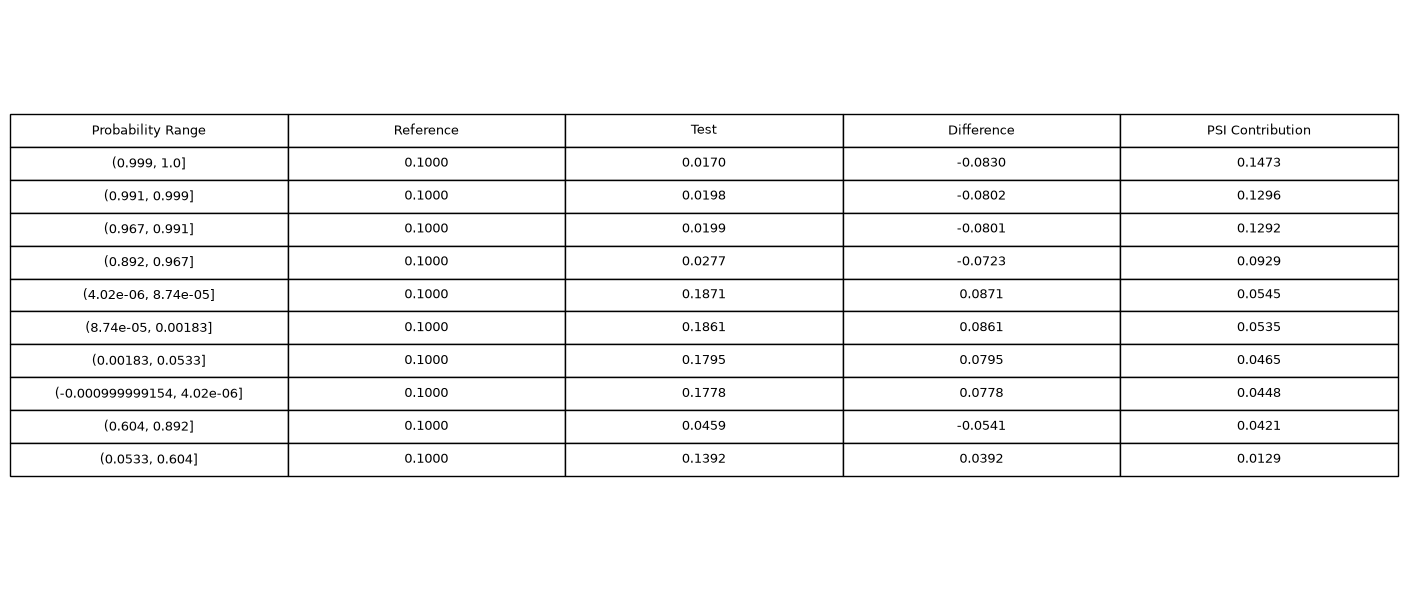

In [117]:
psi_display = psi_comparison.copy()

# Convert the probability ranges (index) into a column
psi_display = psi_display.reset_index()

# Rename the index column
psi_display = psi_display.rename(columns={"probability": "Probability Range"})

# Format numeric columns to exactly 4 decimal places
for col in ["Reference", "Test", "Difference", "PSI Contribution"]:
    psi_display[col] = psi_display[col].map(lambda x: f"{x:.4f}")

# Create the table
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

table = ax.table(cellText=psi_display.values,colLabels=psi_display.columns,cellLoc="center",loc="center")

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.6)

plt.tight_layout()

# Save image
plt.savefig("../images/population_stability_index_psi_summary.png", dpi=300, bbox_inches="tight")
plt.show()

**Bin-level PSI Analysis Summary:**

The bin-level analysis shows a substantial redistribution of model prediction probabilities between the reference and test populations. The largest PSI contributions were observed in the higher probability ranges, particularly (0.999, 1.0], (0.991, 0.999], (0.967, 0.991], and (0.892, 0.967], where the test population proportions were substantially lower than those of the reference population. Conversely, the lower probability ranges showed notable increases in the test population. This indicates a broad shift in the model prediction distribution and highlights the need for further investigation to understand the underlying factors and assess its impact on model performance.

#### Prediction Probability Distribution Analysis

In [118]:
df_reference_probabilities.head()

,probability
0,0.000170
1,0.000005
2,0.001406
3,0.226943
4,0.000273


In [119]:
df_reference_probabilities.shape

(68390, 1)

In [120]:
df_test_probabilities.head()

,probability
0,0.530388
1,0.000011
2,0.005516
3,0.006468
4,0.921477


In [121]:
df_test_probabilities.shape

(12497, 1)

In [122]:
df_reference_probabilities["probability"].describe()

count    6.839000e+04
mean     4.999941e-01
std      4.546133e-01
min      8.460863e-10
25%      3.914045e-04
50%      6.036323e-01
75%      9.819155e-01
max      1.000000e+00
Name: probability, dtype: float64

In [123]:
df_test_probabilities["probability"].describe()

count    1.249700e+04
mean     1.547319e-01
std      3.090301e-01
min      1.237883e-09
25%      1.294346e-05
50%      7.560376e-04
75%      8.045877e-02
max      1.000000e+00
Name: probability, dtype: float64

**Prediction Probability Distribution Analysis:**

The comparison of prediction probability statistics shows a substantial shift between the reference and test populations. The mean prediction probability decreased from 0.4999 in the reference population to 0.1547 in the test population, while the median decreased from 0.6036 to 0.0008. Similarly, the 75th percentile decreased from 0.9819 to 0.0805. These changes indicate that the test population has shifted considerably toward lower model prediction probabilities, consistent with the significant PSI observed earlier. This finding highlights the need for further investigation to understand the underlying factors contributing to the shift and assess its potential impact on model performance.

## PSI & CSI Analysis – Findings and Conclusion

The PSI analysis resulted in a value of 0.7537, indicating a significant shift in the distribution of model prediction probabilities between the reference and test populations. The bin-level analysis showed that the largest PSI contributions came from the higher prediction-probability ranges, where the test population proportions were substantially lower than those of the reference population. Conversely, the lower probability ranges showed notable increases in the test population.

The prediction probability statistics further confirmed this shift, with the mean prediction probability decreasing from 0.4999 in the reference population to 0.1547 in the test population, while the median decreased from 0.6036 to 0.0008.

In contrast, the CSI analysis showed that all 10 features had CSI values below 0.1, indicating that the individual feature distributions remained relatively stable between the reference and test populations.

Overall, the analysis shows a significant shift in the model prediction distribution, while the individual feature distributions remained relatively stable. The PSI and CSI analysis provide the final assessment of the distributional changes observed between the reference and test populations.